# **Метод наименьших квадратов**

Если у нас один признак, и присутствует линейная зависимость

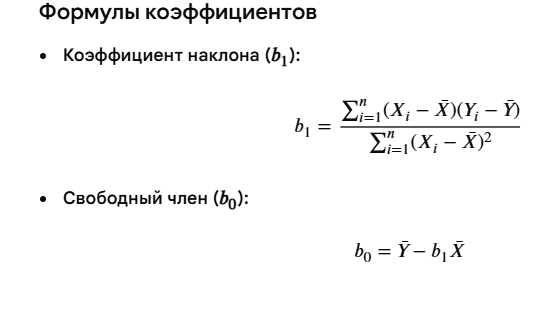

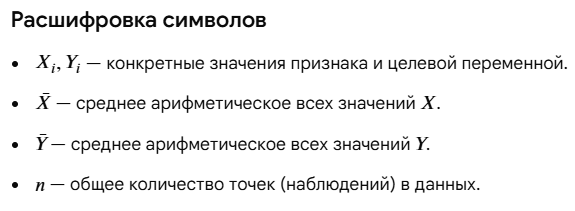

Задание: Прогноз стоимости аренды офиса

Контекст: Аналитику в агентстве недвижимости нужно понять, как площадь офиса (\(X\)) влияет на стоимость его месячной аренды (\(Y\)), и составить формулу для оценки других офисов в этом районе.

In [77]:
x = [20,23,26,29,32,35,45,55,69]  # Площадь кв. м.
y = [5,8,12,14,18,20,22,25,32]    # Стоимость аренды в тыс.
x_new = 40                        # Спрогнозировать стоимость аренды для 40 кв. м.


In [78]:
LEN = len(x)

x_mean = sum(x)/LEN
y_mean = sum(y)/LEN

b_up = 0
for i in range(LEN):
  b_up += (x[i]-x_mean) * (y[i]-y_mean)

b_und = 0
for j in range(LEN):
  b_und += (x[j]-x_mean)**2

b1 = b_up/b_und

b0 = y_mean - b1 * x_mean

### Прогноз можно сделать сделать через:
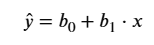

где **x** - новая площадь офиса


In [79]:
y_new = b0 + b1 * x_new
print(f'{round(y_new,3)} предсказанная стоимость аренды.')

18.786 предсказанная стоимость аренды.


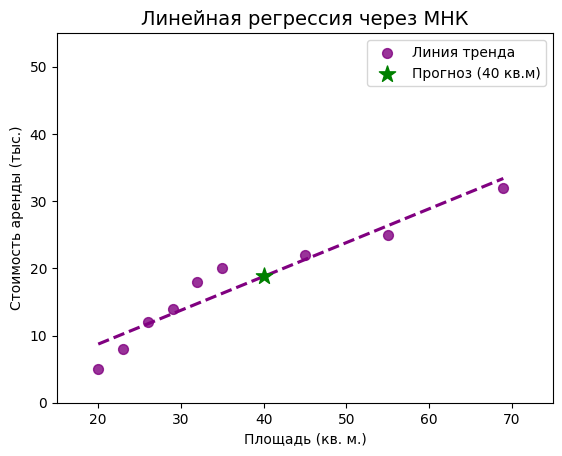

In [80]:
# Визуализация
import seaborn as sns
import matplotlib.pyplot as plt


sns.regplot(x=x, y=y, color="purple",
    scatter_kws={"s": 50},
    line_kws={"linestyle": "--"},
    ci=None,
    label="Линия тренда",
)

plt.scatter(x_new, y_new, color="green",
    marker="*",
    s=150,
    zorder=5,
    label=f"Прогноз ({x_new} кв.м)",
)

plt.title("Линейная регрессия через МНК", fontsize=14)
plt.xlabel("Площадь (кв. м.)")
plt.ylabel("Стоимость аренды (тыс.)")
plt.xlim(15, 75)  # Граница графика по X
plt.ylim(0, 55)  # Граница по Y
plt.legend()

### Сравнение результата с **LinearRegression** из **sklearn**

In [81]:
from sklearn.linear_model import LinearRegression
import pandas as pd
import numpy as np

x_arr = np.array(x)
y_arr = np.array(y)
model = LinearRegression()
model.fit(x_arr.reshape(-1,1),y_arr)
y_pred_LRsk = (model.predict(np.array(x_new).reshape(-1,1))).round(3)
print(f'''Расчитанное значение через sklearn {y_pred_LRsk[0]}
Расчитанное значение через МНК {round(y_new,3)}

Коэффициент из sklearn {model.coef_[0].round(3)}
Коэффициент через МНК {round(b1,3)}

Cмещение из sklearn {model.intercept_.round(3)}
Смешение из МНК {round(b0,3)}''')


Расчитанное значение через sklearn 18.786
Расчитанное значение через МНК 18.786

Коэффициент из sklearn 0.503
Коэффициент через МНК 0.503

Cмещение из sklearn -1.332
Смешение из МНК -1.332


# **Матричный метод наименьших квадратов**

$$b = (X^T X)^{-1} X^T y$$

где **Х** - матрица признаков

**y** - эталонные значения

Выше использовал одномерный МНК. Если добавить к площади квартиры новые факторы (например, расстояние до метро, количество комнат, этаж), то формулы через циклы стали бы огромными и запутанными.

В матричном виде формула \(b = (X^T X)^{-1} X^T y\) остается абсолютно неизменной, сколько бы признаков у вас ни было (хоть 2, хоть 100). Матрица \(X\) просто расширяется новыми столбцами.

In [82]:
from sklearn.datasets import fetch_california_housing
housing = fetch_california_housing(as_frame=True)
df = housing.frame
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   MedInc       20640 non-null  float64
 1   HouseAge     20640 non-null  float64
 2   AveRooms     20640 non-null  float64
 3   AveBedrms    20640 non-null  float64
 4   Population   20640 non-null  float64
 5   AveOccup     20640 non-null  float64
 6   Latitude     20640 non-null  float64
 7   Longitude    20640 non-null  float64
 8   MedHouseVal  20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB


В датасете 8 входных признаков:
MedInc (Median Income) — медианный доход семей в квартале (измеряется в десятках тысяч долларов, например 3.5 = $35 000).

HouseAge (Median House Age) — медианный возраст домов в квартале (сколько лет назад они были построены).

AveRooms (Average Rooms) — среднее количество комнат в домах этого квартала.

AveBedrms (Average Bedrooms) — среднее количество спален в домах.

Population — общее количество жителей в данном квартале.

AveOccup (Average Occupancy) — среднее количество членов семьи, проживающих в одном доме (вычисляется как Популяция / Количество домов).

Latitude — географическая широта квартала.

Longitude — географическая долгота квартала.

Для наглядности буду использовать все признаки для прогнозирования **MedHouseVal**  

In [83]:
def split_for_fit(df, split_ratio = 2/3):
  """Разделение данных на обучающую и тестовую"""
  num = int(df.shape[0] * split_ratio)
  return df.iloc[:num], df.iloc[num+1:]


In [84]:
X = df.drop('MedHouseVal', axis = 1)
y = df.MedHouseVal


X_train, X_test = split_for_fit(X)
y_train, y_test = split_for_fit(y)

X_intercept = np.column_stack((np.ones(len(X_train)), X_train))
b = np.linalg.inv(X_intercept.T @ X_intercept) @ X_intercept.T @ y_train  #  Получили вес всех признаков + кф. смещения



In [85]:
#  Прогноз


X_intercept_test = np.column_stack((np.ones(len(X_test)), X_test))
y_pred = X_intercept_test @ b

results = pd.DataFrame({
    'test': y_test,
    'pred_linalg': y_pred
})

results.head()

,test,pred_linalg
13761,1.313,1.829282
13762,1.030,1.103715
13763,1.208,0.737456
13764,1.632,1.993361
13765,0.869,1.374924


### Сравнение результата с **LinearRegression** из **sklearn**

In [86]:
model_two = LinearRegression()
model_two.fit(X_train, y_train)
results['pred_SKlr'] = model_two.predict(X_test)

results.head()

,test,pred_linalg,pred_SKlr
13761,1.313,1.829282,1.829282
13762,1.030,1.103715,1.103715
13763,1.208,0.737456,0.737456
13764,1.632,1.993361,1.993361
13765,0.869,1.374924,1.374924


In [87]:
f'Разность предсказаний между матричным методом и регресии из sklearn {sum((results.pred_linalg - results.pred_SKlr).round(3))}'

'Разность предсказаний между матричным методом и регресии из sklearn 0.0'

# **Аналитический метод через градиентный спуск**

Формула MSE

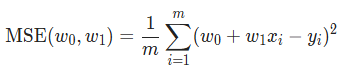

Формула чатных производных

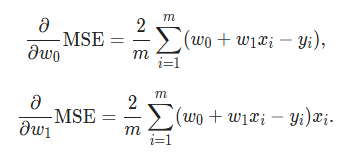

Обновление шагов градиентного спуска для каждой эпохи

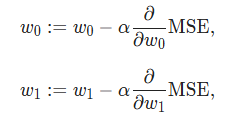

 Использую градиент из задачи МНК

In [88]:
import math


xi = [20,23,26,29,32,35,45,55,69]  # Площадь кв. м.
yi = [5,8,12,14,18,20,22,25,32]    # Стоимость аренды в тыс.
x_new = 40                        # Спрогнозировать стоимость аренды для 40 кв. м.


m = len(xi)

# Гиперпараметры
learn_rate = 0.0005
epochs = 80000  # Добавили количество итераций


w0 = 0.0
w1 = 0.0

# Критерий остановки
epsil = 0.00000001

# Градиентный спуск
for epoch in range(epochs):

    # Старые веста
    w0_old = w0
    w1_old = w1

    # Предсказания для текущих весов
    y_pred = [w0 + w1 * x for x in xi]

    # Подсчет градиентов
    dif0 = 0.0
    dif1 = 0.0
    for i in range(m):
        error = y_pred[i] - yi[i]
        dif0 += error
        dif1 += error * xi[i]

    w0_n = dif0 * (2 / m)
    w1_n = dif1 * (2 / m)

    # Обновление весов
    w0 -= learn_rate * w0_n
    w1 -= learn_rate * w1_n

    if abs(w0-w0_old) <= epsil and abs(w1-w1_old) <= epsil:
      #print(epoch) Количество прошедших эпох
      break


ans = (w0 + w1 * x_new)
print(f'''Итоговые веса модели и сравнение с МНК

Смещение через градиент {round(w0,3)}
        Смешение из МНК {round(b0,3)}

Наклон через градиент {round(w1,3)}
     Наклон через МНК {round(b1,3)}

Прогноз через Градиент {round(ans,3)}
     Прогноз через МНК {round(y_new,3)}
''')

Итоговые веса модели и сравнение с МНК

Смещение через градиент -1.332
        Смешение из МНК -1.332
      
Наклон через градиент 0.503
     Наклон через МНК 0.503
      
Прогноз через Градиент 18.786
     Прогноз через МНК 18.786

